In [1]:
import h5py
import numpy as np
import os
import pandas as pd
import pathlib
import pickle
import scipy.stats as stats
import soxr
#! change below to spatial_attn_lighting if want to use with modular 
import src.spatial_attn_lightning as attn_tracking_lightning
import torch
import yaml

from argparse import ArgumentParser
from corpus.speaker_room_dataset import SpeakerRoomDataset
from tqdm.auto import tqdm

import IPython.display as ipd

torch.set_float32_matmul_precision('medium') # use same as training
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

/om2/user/imgriff/conda_envs/pytorch_2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset = SpeakerRoomDataset('/om2/user/rphess/Auditory-Attention/final_binaural_manifest.pkl', '/om2/user/msaddler/spatial_audio_pipeline/assets/swc/manifest_all_words.pdpkl', 'voice_and_location')

In [3]:
new_room_manifest = pd.read_pickle('/om2/user/msaddler/spatial_audio_pipeline/assets/brir/mit_bldg46room1004/manifest_brir.pdpkl')
only14_manifest = new_room_manifest[(new_room_manifest['src_dist'] == 1.4) & (new_room_manifest['index_room'] == 0)]

In [4]:
class Spatialize(torch.nn.Module):
    def __init__(self, ir):
        super(Spatialize, self).__init__()
        ir = torch.flip(torch.from_numpy(ir), dims=[0])
        ir = ir.T.unsqueeze(1)
        self.ir = torch.nn.Parameter(ir, requires_grad=False)

    def forward(self, words):
        n_words = words.shape[0]
        # pad last dim of words with ir.shape[0] - 1 zeros
        words_padded = torch.nn.functional.pad(words, (self.ir.shape[0] - 1, 0))
        spatialized = torch.nn.functional.conv1d(words_padded.view(n_words, 1, -1), self.ir)
        # resize to desired shape
        spatialized = spatialized[:, :, 12500:137500]
        return spatialized

In [5]:
ir_dict = dict()
for loc in ['target', 'distractor', 'cue']:
    if loc == 'target':
        coords = (0,0)
    elif loc == 'distractor':
        coords = (0,0)
    else:
        coords = (0,0)
    df_row = only14_manifest[(only14_manifest['src_azim'] == coords[0]) & (only14_manifest['src_elev'] == coords[1])]
    h5_fn = f'/om2/user/msaddler/spatial_audio_pipeline/assets/brir/mit_bldg46room1004/room000{df_row["index_room"].values[0]}.hdf5'
    index_brir = df_row['index_brir'].values[0]
    sr_src = df_row['sr'].values[0]
    with h5py.File(h5_fn, 'r') as f:
        brir = f['brir'][index_brir]
    sr = 50000
    brir = soxr.resample(brir.astype(np.float32), sr_src, sr)
    ir_dict[loc] = brir

tar_brir = Spatialize(ir_dict['target']).cuda()
dist_brir = Spatialize(ir_dict['distractor']).cuda()
cue_brir = Spatialize(ir_dict['cue']).cuda()

In [6]:
config = yaml.load(open('/om2/user/imgriff/projects/torch_2_aud_attn/config/binaural_attn/word_task_voice_and_loc_cue_v04.yml', 'r'), Loader=yaml.FullLoader)
config['num_workers'] = 12
config['hparas']['batch_size'] = 40 # config['data']['loader']['batch_size'] // args.gpus
config['noise_kwargs']['low_snr'] = 0
config['noise_kwargs']['high_snr'] = 0

In [7]:
model = attn_tracking_lightning.BinauralAttentionModule.load_from_checkpoint(checkpoint_path='/om2/user/imgriff/projects/torch_2_aud_attn/attn_cue_models/word_task_voice_and_loc_cue_v04/checkpoints/epoch=4-step=47248.ckpt', config=config, strict=False).cuda()
audio_transforms = model.audio_transforms.cuda()
# to inference mode 
model = model.eval()
coch_gram = model.coch_gram.cuda()

num_classes={'num_words': 800}
Model performing word task


/om2/user/imgriff/conda_envs/pytorch_2/lib/python3.11/site-packages/torchaudio/functional/functional.py:1371: UserWarning: "kaiser_window" resampling method name is being deprecated and replaced by "sinc_interp_kaiser" in the next release. The default behavior remains unchanged.
  warnings.warn(


center_crop=True
binaural=True
Binaural cochleagram
using FIR cochleagram


In [8]:
cue, fg, bg, label, confusion = dataset[1]

cue = cue_brir(cue.cuda().view(1, -1))
foreground = tar_brir(fg.cuda().view(1, -1))
background = dist_brir(bg.cuda().view(1, -1))

In [9]:
cue = audio_transforms(cue, None)[0]
mixture = audio_transforms(foreground, background)[0]

In [47]:
ipd.display(ipd.Audio(cue[0].cpu(), rate=50000))
ipd.display(ipd.Audio(mixture[0].cpu(), rate=50000))
manifest.iloc[1]

src_ix              685994
client_id         0x0077be
corpus                 swc
gender                male
gender_int               1
split                  NaN
split_int                0
word                showed
cue_word         provision
cue_src_ix          686394
cue_client_id     0x0077be
bg_word            british
bg_src_ix           602661
bg_client_id       laura-s
bg_gender           female
Name: 1, dtype: object

In [10]:
cue, mixture = coch_gram(cue, mixture)

In [58]:
%matplotlib inline
import matplotlib.pyplot as plt

In [68]:
mixture.shape

torch.Size([1, 2, 40, 20000])

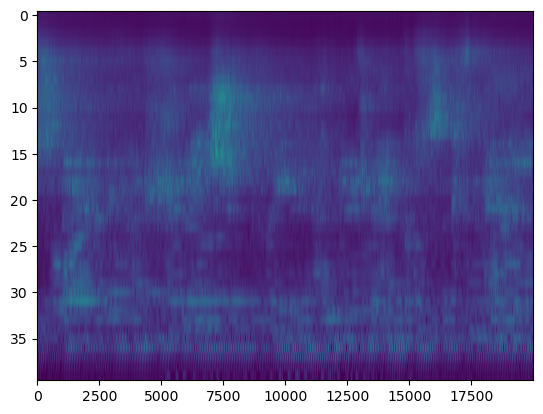

In [62]:
plt.imshow(mixture[0][0].cpu(), aspect='auto')
plt.show()

In [11]:
model.model(cue, mixture, None).softmax(dim=-1).argmax(dim=-1).cpu().detach().numpy().astype('int')

array([526])

In [12]:
label

618

In [13]:
with open('final_binaural_manifest.pkl', 'rb') as f:
    manifest = pd.read_pickle(f)

In [13]:
manifest.iloc[1]

NameError: name 'manifest' is not defined